In [14]:
%pip install seaborn

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import LinearSVC  # clasificador para texto
import matplotlib.pyplot as plt
import seaborn as sns  # opcional


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\light\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
# Carga del CSV con tus ejemplos
df = pd.read_csv("dudas_python_temas.csv")

print(df.head())
print(df['label'].value_counts())


                                             texto              label
0                  ¿Qué es una variable en Python?  variables_y_tipos
1                    ¿Para qué sirve una variable?  variables_y_tipos
2  ¿Cuál es la diferencia entre un int y un float?  variables_y_tipos
3              ¿Cómo convierto un número a cadena?  variables_y_tipos
4                       ¿Qué tipo de dato es True?  variables_y_tipos
label
variables_y_tipos       30
control_de_flujo        30
funciones               30
estructuras_de_datos    30
errores_y_debugging     30
io_archivos             30
poo                     29
Name: count, dtype: int64


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),     # unigrams y bigrams
        max_df=0.85,            # ignora términos muy generales si hiciera falta
        min_df=1
    )),
    ("clf", LinearSVC())
])


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    df["texto"], df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]  # para balancear por tema
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))


                      precision    recall  f1-score   support

    control_de_flujo       0.67      0.67      0.67         6
 errores_y_debugging       0.67      0.67      0.67         6
estructuras_de_datos       1.00      0.67      0.80         6
           funciones       0.44      0.67      0.53         6
         io_archivos       0.80      0.67      0.73         6
                 poo       0.80      0.67      0.73         6
   variables_y_tipos       0.57      0.67      0.62         6

            accuracy                           0.67        42
           macro avg       0.71      0.67      0.68        42
        weighted avg       0.71      0.67      0.68        42



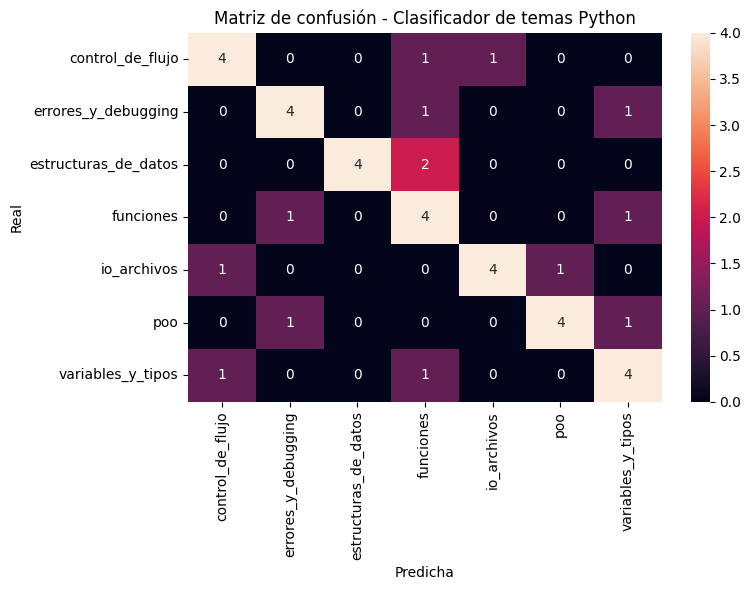

In [22]:
cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=pipeline.classes_,
            yticklabels=pipeline.classes_)
plt.xlabel("Predicha")
plt.ylabel("Real")
plt.title("Matriz de confusión - Clasificador de temas Python")
plt.tight_layout()
plt.show()


In [19]:
import joblib

joblib.dump(pipeline, "modelo_temas_python.pkl")


['modelo_temas_python.pkl']

In [21]:
ejemplos = [
    "No entiendo cómo funciona un bucle for?",
    "Qué significa TypeError: NoneType?",
    "Cómo abrir un archivo y leer líneas?",
    "Qué diferencia hay entre una lista y un set?",
    "Qué es self en Python?"
]

for e in ejemplos:
    print(e, "→", pipeline.predict([e])[0])


No entiendo cómo funciona un bucle for? → control_de_flujo
Qué significa TypeError: NoneType? → errores_y_debugging
Cómo abrir un archivo y leer líneas? → io_archivos
Qué diferencia hay entre una lista y un set? → estructuras_de_datos
Qué es self en Python? → poo
